In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import *

In [2]:
# Load dataset
ds = load_jsonl_file('./../datasets/MATE-dev/mm_0shot_llava_hfllava_1.5_7b_hf.jsonl')
nobjects=3

# Filter dataset for a specific number of objects 
ds_ = [data for data in ds if data['object_count'] == nobjects]

5500it [00:00, 7884.71it/s] 


./results/llava7B/linear_probing/image/probing_results_color_red_3.csv
./results/llava7B/linear_probing/image/probing_results_color_blue_3.csv
./results/llava7B/linear_probing/image/probing_results_color_green_3.csv
./results/llava7B/linear_probing/image/probing_results_color_yellow_3.csv
./results/llava7B/linear_probing/image/probing_results_color_gray_3.csv


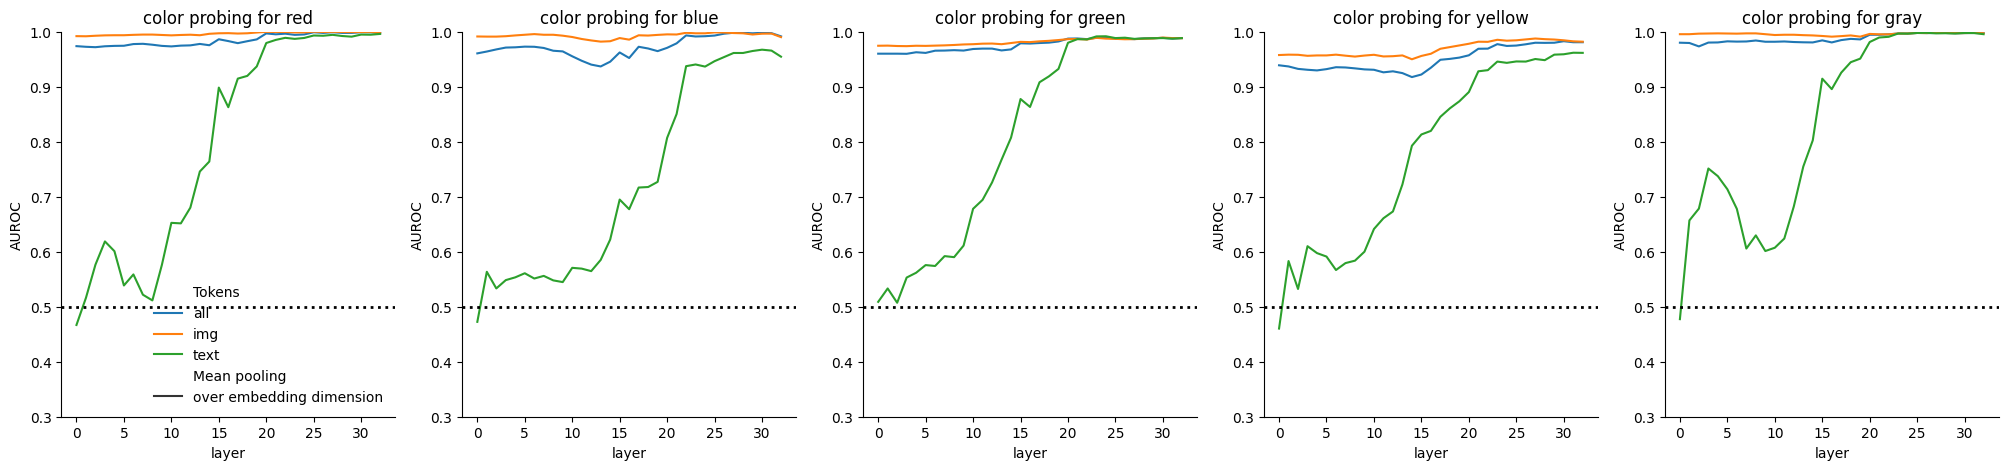

In [16]:
###### plot color probe results
task='color'
targets=['red', 'blue','green','yellow', 'gray']
metric = 'auroc'  # 'auroc', 'accuracy', 'auprc'
mode = 'image'  # 'image', 'text'

fig,axs = plt.subplots(1, len(targets), figsize=(5*len(targets), 5))

for idx, target in enumerate(targets):
    task_df = pd.read_csv(f"./results/llava7B/linear_probing/{mode}/probing_results_{task}_{target}_{nobjects}.csv", index_col=0)
    print(f"./results/llava7B/linear_probing/{mode}/probing_results_{task}_{target}_{nobjects}.csv")
    task_df['Mean pooling'] = [i.split('_')[0] for i in task_df['embedding_level']]
    task_df['Mean pooling'] = ['over embedding dimension' if i=='sentence' else 'over token' for i in task_df['Mean pooling']]
    task_df['Tokens'] = [i.split('_')[1] for i in task_df['embedding_level']]
    task_df = task_df[task_df['Mean pooling']=='over embedding dimension']
    

    b = sns.lineplot(data=task_df,
                        x='layer', y=metric, hue='Tokens',style='Mean pooling',
                        ax=axs[idx])
    
    gold_reference = ['Yes' if target in set([o['color'] for o in data['scene']['objects']]) else 'No' for data in ds_]
    gold_reference_binary = [1 if i=='Yes' else 0 for i in gold_reference]
    baseline = np.sum(gold_reference_binary) / len(gold_reference_binary)
    baseline = 0.5

    b.axhline(y=baseline, color='black', linestyle=':', linewidth=2)
    b.set_title(f"{task} probing for {target}")
    b.set_ylabel(metric.upper())

    if idx == 0:
        b.legend(frameon=False)
    else:
        b.legend_.remove()

    b.set(ylim=(0.3,1))


sns.despine(top=True, right=True)

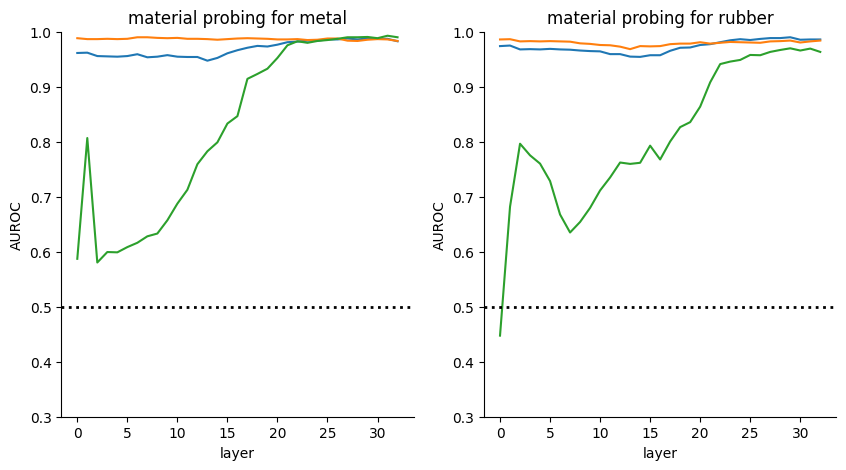

In [ ]:
###### plot material probe results
task='material'
targets=['metal', 'rubber']
metric = 'auroc'  # 'auroc', 'accuracy', 'auprc'
mode = 'image'  # 'image', 'text'

fig,axs = plt.subplots(1, len(targets), figsize=(5*len(targets), 5))

for idx, target in enumerate(targets):
    task_df = pd.read_csv(f"./results/llava7B/linear_probing/{mode}/probing_results_{task}_{target}_{nobjects}.csv", index_col=0)

    task_df['Mean pooling'] = [i.split('_')[0] for i in task_df['embedding_level']]
    task_df['Mean pooling'] = ['over embedding dimension' if i=='sentence' else 'over token' for i in task_df['Mean pooling']]
    task_df['Tokens'] = [i.split('_')[1] for i in task_df['embedding_level']]
    task_df = task_df[task_df['Mean pooling']=='over embedding dimension']

    b = sns.lineplot(data=task_df,
                        x='layer', y=metric, hue='Tokens', style='Mean pooling',
                        ax=axs[idx])
    baseline = 0.5

    b.axhline(y=baseline, color='black', linestyle=':', linewidth=2)
    b.set_title(f"{task} probing for {target}")
    b.set_ylabel(metric.upper())

    # if idx == 0:
    #     b.legend(frameon=False)
    # else:
    b.legend_.remove()

    b.set(ylim=(0.3,1))


sns.despine(top=True, right=True)

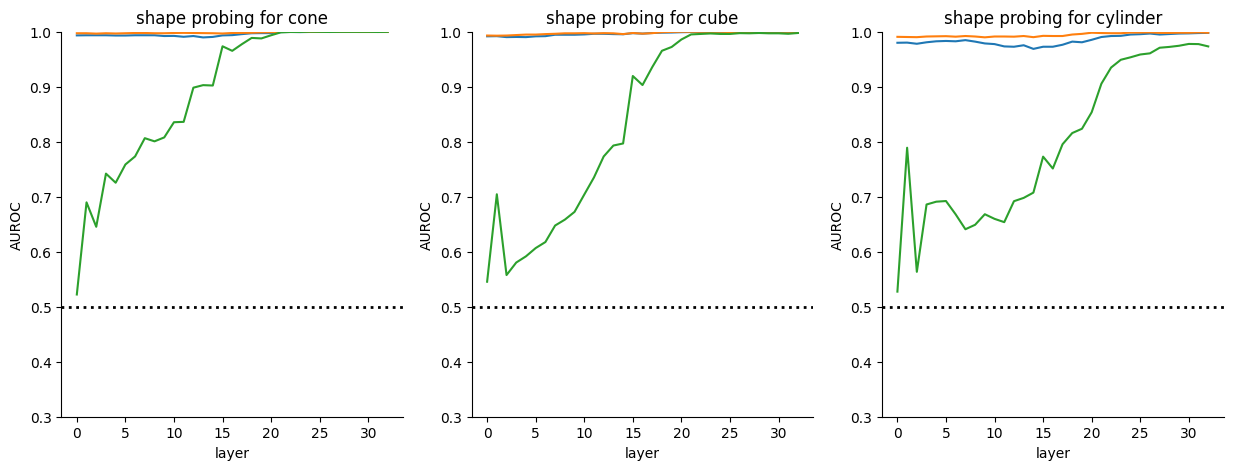

In [12]:
###### plot shape probe results
task='shape'
targets=['cone', 'cube', 'cylinder']
metric = 'auroc'  # 'auroc', 'accuracy', 'auprc'
mode = 'image'  # 'image', 'text'

fig,axs = plt.subplots(1, len(targets), figsize=(5*len(targets), 5))

for idx, target in enumerate(targets):
    task_df = pd.read_csv(f"./results/llava7B/linear_probing/{mode}/probing_results_{task}_{target}_{nobjects}.csv", index_col=0)

    task_df['Mean pooling'] = [i.split('_')[0] for i in task_df['embedding_level']]
    task_df['Mean pooling'] = ['over embedding dimension' if i=='sentence' else 'over token' for i in task_df['Mean pooling']]
    task_df['Tokens'] = [i.split('_')[1] for i in task_df['embedding_level']]
    task_df = task_df[task_df['Mean pooling']=='over embedding dimension']

    b = sns.lineplot(data=task_df,
                        x='layer', y=metric, hue='Tokens', style='Mean pooling',
                        ax=axs[idx])
    baseline = 0.5

    b.axhline(y=baseline, color='black', linestyle=':', linewidth=2)
    b.set_title(f"{task} probing for {target}")
    b.set_ylabel(metric.upper())

    # if idx == 0:
    #     b.legend(frameon=False)
    # else:
    b.legend_.remove()

    b.set(ylim=(0.3,1))


sns.despine(top=True, right=True)

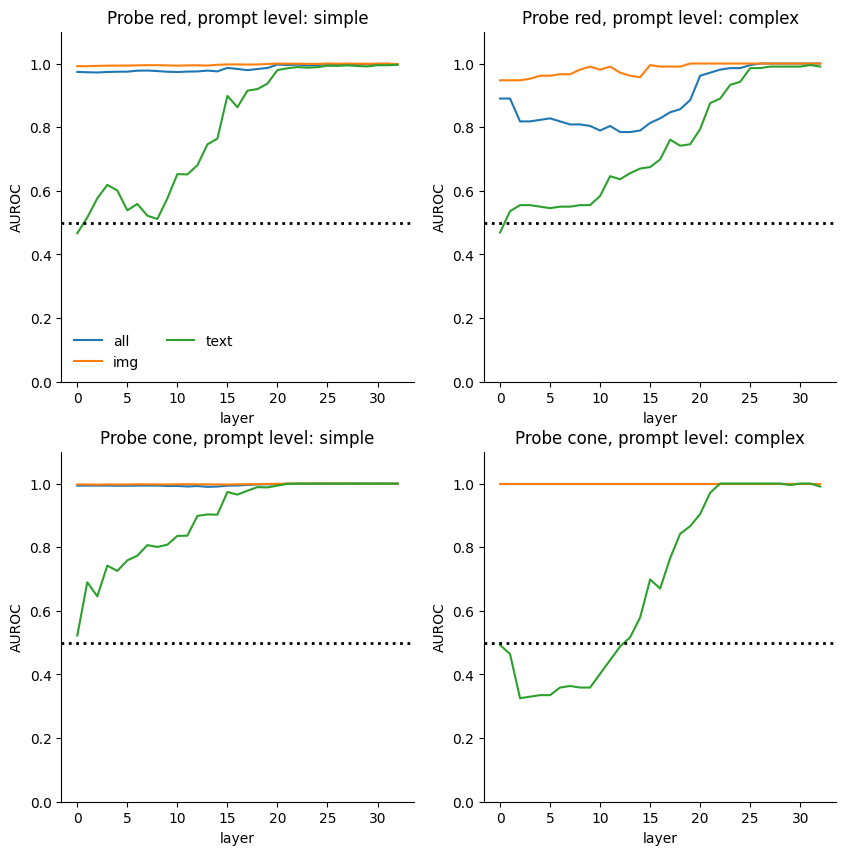

In [3]:
###### plot color probe results
tasks = ['color','shape']
targets = ['red','cone']
metric = 'auroc'  # 'auroc', 'accuracy', 'auprc'
mode = 'image'  # 'image', 'text'
prompt_level=['simple', 'complex']
fig,axs = plt.subplots(len(tasks), len(prompt_level), figsize=(5*len(prompt_level), 5*len(tasks)))

for idx,(task,target) in enumerate(zip(tasks, targets)): 
    for jdx, prompt_type in enumerate(prompt_level): 
        if prompt_type=='simple':
            task_df = pd.read_csv(f"./results/llava7B/linear_probing/{mode}/probing_results_{task}_{target}_{nobjects}.csv", index_col=0)
        else:
            task_df = pd.read_csv(f"./results/llava7B/linear_probing/{mode}/{prompt_type}/probing_results_{task}_{target}_{nobjects}.csv", index_col=0)
    
        task_df['Mean pooling'] = [i.split('_')[0] for i in task_df['embedding_level']]
        task_df['Mean pooling'] = ['over embedding dimension' if i=='sentence' else 'over token' for i in task_df['Mean pooling']]
        task_df['Tokens'] = [i.split('_')[1] for i in task_df['embedding_level']]
        task_df = task_df[task_df['Mean pooling']=='over embedding dimension']

        b = sns.lineplot(data=task_df,
                            x='layer', y=metric, hue='Tokens',
                            ax=axs[idx][jdx])
        baseline = 0.5

        b.axhline(y=baseline, color='black', linestyle=':', linewidth=2)
        b.set_title(f"Probe {target}, prompt level: {prompt_type}")
        b.set_ylabel(metric.upper())
        
        if idx == 0 and jdx==0:
            b.legend(frameon=False, ncols=2)
        else:
            b.legend_.remove()

        b.set(ylim=(0,1.1))

sns.despine(top=True, right=True)

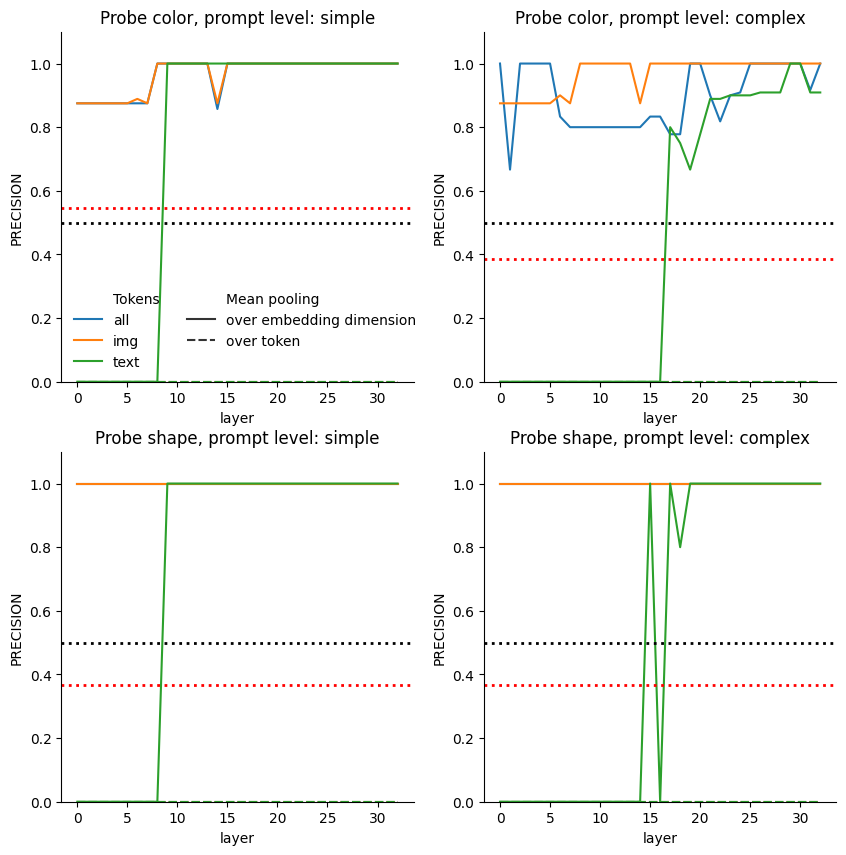

In [9]:
###### plot color probe results
tasks = ['color','shape']
targets = ['red','cone']
metric = 'precision'  # 'auroc', 'accuracy', 'auprc'
mode = 'image'  # 'image', 'text'
prompt_level=['simple', 'complex']
fig,axs = plt.subplots(len(tasks), len(prompt_level), figsize=(5*len(prompt_level), 5*len(tasks)))

for idx,(task,target) in enumerate(zip(tasks, targets)): 
    for jdx, prompt_type in enumerate(prompt_level): 
        task_df = pd.read_csv(f"./results/llava7B/linear_probing/{mode}/{prompt_type}/probing_results_{task}_{target}_{nobjects}.csv", index_col=0)
        vlm_results_df = pd.read_csv(f"./results/llava7B/linear_probing/{mode}/{prompt_type}/vlm_results_{task}_{target}_{nobjects}.csv", index_col=0)   

        task_df['Mean pooling'] = [i.split('_')[0] for i in task_df['embedding_level']]
        task_df['Mean pooling'] = ['over embedding dimension' if i=='sentence' else 'over token' for i in task_df['Mean pooling']]
        task_df['Tokens'] = [i.split('_')[1] for i in task_df['embedding_level']]

        b = sns.lineplot(data=task_df,
                            x='layer', y=metric, hue='Tokens', style='Mean pooling',
                            ax=axs[idx][jdx])
        baseline = 0.5

        b.axhline(y=baseline, color='black', linestyle=':', linewidth=2)
        b.axhline(y=vlm_results_df[metric].item(), color='red', linestyle=':', linewidth=2)
        b.set_title(f"Probe {task}, prompt level: {prompt_type}")
        b.set_ylabel(metric.upper())
        
        if idx == 0 and jdx==0:
            b.legend(frameon=False, ncols=2)
        else:
            b.legend_.remove()

        b.set(ylim=(0,1.1))

sns.despine(top=True, right=True)